# Domain 5, Method 1: Bayesian hierarchical zero-dose model with DHIS2-calibrated LGA allocation

**National Primary Health Care Development Agency (NPHCDA) - Predictive Modelling of Zero-Dose Children.**
Prepared by the CIDRE and Quantium Insights LLC consortium, with UNICEF and Gavi.

A *zero-dose child* is a child aged 12-23 months who has not received the first dose of the pentavalent vaccine (Penta1 / DTP1).

**What this notebook does**
1. Fits a Bayesian hierarchical Beta regression of state zero-dose prevalence on the Nigeria Demographic and Health Surveys (NDHS) 2008, 2013, 2018 and 2023-24, with zone and state effects and a DHIS2 Penta1 trend term, and forecasts 2026-2028 with credible intervals.
2. Converts state rates to numbers of zero-dose children using the 12-23-month cohort (state under-five population, 2024 projection, divided by five).
3. Distributes each state's estimate to its local government areas (LGAs) using each LGA's share of DHIS2 Penta1 doses and its National Population Commission (NPC) 2022 population (773 LGAs; Guzamala, Borno reported no Penta1 doses in 2021-2024, the allocation years; partial reporting began in 2025).
4. Ranks LGAs, computes burden concentration (LGAs needed for 50%, 60% and 80% of zero-dose children), Getis-Ord Gi* hotspots, and checks the results against two independent sources (NmDHS 2025-26 and the IHME DTP1 2018 LGA surface).

**How to run:** Runtime > Run all. When prompted, upload the files from the folder `Method1_Bayesian_Hierarchical_Model` of *Updated Datasets for Domain 5*. Expected run time: 3-6 minutes on Colab.

In [1]:
# ---- Setup: works in Google Colab and locally ------------------------------------------------
import os, sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REQUIRED = ['nigeria_ndhs_zero_dose_VERIFIED_long.csv', 'under_5_2024.csv', 'under_5_2025.csv', 'dhis2_data_all_states.csv', 'administrative_lga_population.csv', 'nga_lgas.geojson', 'nga_states.geojson', 'ihme_dtp1_admin2_2018.csv', 'nmdhs_2025_26_penta1_by_state_zone.csv']

if IN_COLAB:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + ['pymc', 'nutpie', 'arviz', 'geopandas', 'libpysal', 'esda', 'openpyxl'], check=False)
    DATA_DIR = Path("/content/data"); DATA_DIR.mkdir(exist_ok=True)
    # Option A (default): upload the files from the matching folder of "Updated Datasets for Domain 5".
    # Option B: mount Google Drive and point DATA_DIR at the folder, e.g.
    #   from google.colab import drive; drive.mount("/content/drive")
    #   DATA_DIR = Path("/content/drive/MyDrive/Updated Datasets for Domain 5/<folder>")
    missing = [f for f in REQUIRED if not (DATA_DIR / f).exists()]
    if missing:
        from google.colab import files
        print("Please select these files (you can select them all at once):", missing)
        for name, content in files.upload().items():
            (DATA_DIR / name).write_bytes(content)
else:
    DATA_DIR = Path(os.environ.get("D5_DATA_DIR", ".")).resolve()

OUT_DIR = Path(os.environ.get("D5_OUT_DIR", "outputs")).resolve(); OUT_DIR.mkdir(parents=True, exist_ok=True)
missing = [f for f in REQUIRED if not (DATA_DIR / f).exists()]
assert not missing, f"Missing input files in {DATA_DIR}: {missing}"
print("Data folder:", DATA_DIR.name, "| all", len(REQUIRED), "input files found | outputs ->", OUT_DIR.name)

Data folder: Method1_Bayesian_Hierarchical_Model | all 9 input files found | outputs -> outputs_Method1_Bayesian_Hierarchical_Model


In [2]:
# ---- LGA / state name harmonisation (DHIS2, NPC population file, GRID3 and IHME spell names differently)
import re, difflib
import numpy as np, pandas as pd

def clean_lga_name(s):
    """Remove the 2-letter DHIS2 state prefix and the 'Local Government Area' suffix."""
    s = str(s).strip()
    s = re.sub(r"^[a-z]{2}\s+", "", s, flags=re.IGNORECASE)
    s = re.sub(r"\s*local\s+government\s+area\s*$", "", s, flags=re.IGNORECASE)
    return s.strip().title()

def nstate(s):
    s = str(s).lower().strip()
    if "federal capital" in s or s in ("fct", "fct, abuja"):
        return "fct"
    return re.sub(r"\(.*?\)", "", s).strip()

def nlga(s):
    s = re.sub(r"\(.*?\)|\[.*?\]", "", str(s).lower().strip())
    return re.sub(r"\s+", " ", s.replace("'", "").replace("/", " ").replace("-", " ").replace(".", "")).strip()

def tok(s):
    return " ".join(sorted(nlga(s).split()))

LGA_ALIAS = {("kebbi", "arewa"): "arewa dandi", ("imo", "ezinihitte mbaise"): "ezinihitte",
             ("ekiti", "aiyekire"): "gbonyin"}
FCT6 = {"Abaji", "Abuja Municipal Area Council", "Bwari", "Gwagwalada", "Kuje", "Kwali"}

def make_matcher(keys_by_state):
    """Return f(state_key, lga) -> matched key: exact, alias, token-sorted, then close match (cutoff 0.75)."""
    def match(sk, lga):
        l = nlga(lga); cands = keys_by_state.get(sk, [])
        if l in cands: return l, "exact"
        a = LGA_ALIAS.get((sk, l))
        if a in cands: return a, "alias"
        tk = {tok(c): c for c in cands}
        if tok(l) in tk: return tk[tok(l)], "token"
        c = difflib.get_close_matches(l, cands, n=1, cutoff=0.75)
        return (c[0], "close") if c else (None, "unmatched")
    return match

## 1. Load and check the data
DHIS2 exports print large numbers with thousands separators (for example `1,234`). Reading the file with `thousands=","` keeps those values; reading them as plain text would silently turn them into missing values.

In [3]:
ndhs = pd.read_csv(DATA_DIR / "nigeria_ndhs_zero_dose_VERIFIED_long.csv")
dh = pd.read_csv(DATA_DIR / "dhis2_data_all_states.csv", thousands=",", low_memory=False)
pop_raw = pd.read_csv(DATA_DIR / "administrative_lga_population.csv")

def prep_under5(path):
    u = pd.read_csv(path).iloc[1:].copy()          # first data row repeats the header
    u.columns = ["zone_abbr", "state_raw", "under5"]
    u["under5_n"] = u["under5"].astype(str).str.replace(",", "").str.strip().astype(float)
    u["cohort_12_23m"] = (u["under5_n"] / 5).round(0)
    u["jk"] = u["state_raw"].str.strip().str.upper().str.replace(" ", "").str.replace(",ABUJA", "").str.replace(",", "")
    return u
u5 = prep_under5(DATA_DIR / "under_5_2024.csv")

dh["ds"] = pd.to_datetime(dh["period"].astype(str).str.strip(), format="%b-%y")
dh["year"] = dh["ds"].dt.year
for c in ("zone", "state", "lga"):
    dh[c] = dh[c].astype(str).str.strip()
dh["lga_clean"] = dh["lga"].map(clean_lga_name)

print("NDHS state-waves:", len(ndhs), "| states:", ndhs.state.nunique(), "| waves:", sorted(ndhs.year.unique()))
print("DHIS2 rows:", len(dh), "| LGAs:", dh[["state", "lga_clean"]].drop_duplicates().shape[0],
      "| months:", dh.ds.nunique(), f"({dh.ds.min():%b %Y} to {dh.ds.max():%b %Y})")
print("Penta1 numeric:", pd.api.types.is_numeric_dtype(dh.penta_1_count), "| blank Penta1 LGA-months:", int(dh.penta_1_count.isna().sum()))
assert dh[["state", "lga_clean"]].drop_duplicates().shape[0] == 774
assert ndhs.state.nunique() == 37 and len(ndhs) == 148

NDHS state-waves: 148 | states: 37 | waves: [np.int64(2008), np.int64(2013), np.int64(2018), np.int64(2024)]
DHIS2 rows: 43656 | LGAs: 774 | months: 60 (Jan 2021 to Dec 2025)
Penta1 numeric: True | blank Penta1 LGA-months: 278


## 2. State model: Bayesian hierarchical Beta regression

For state $s$ in zone $z$ and survey round $i$ (year standardised as $t_i$):

$$y_i \sim \mathrm{Beta}(\mu_i\kappa_i,\,(1-\mu_i)\kappa_i), \qquad \mathrm{logit}\,\mu_i = \alpha_s + \beta_s t_i + \gamma x_s, \qquad \kappa_i = \kappa_b\, n_i/\bar n$$

* $y_i$: NDHS zero-dose proportion (100 minus DTP1 coverage), $n_i$: number of children in the survey table.
* $\alpha_s, \beta_s$: state intercept and time trend, partially pooled towards zone values, which are pooled towards a national mean (non-centred parameterisation).
* $x_s$: standardised DHIS2 Penta1 trend, $\log(\text{Penta1}_{2025}/\text{Penta1}_{2023})/2$, computed over 2023-2025, the period with complete Penta1 reporting for all 37 states.
* Priors: $\mu_\alpha, \beta_g \sim N(0,1)$; $\gamma \sim N(0,0.5)$; zone and state scales $\sim$ Half-Normal(0.5) for intercepts and (0.3) for slopes; $\kappa_b \sim$ Gamma(2, 0.5).

In [4]:
YEAR_CENTER = 2024
long_df = ndhs.copy()
year_std = long_df["year"].std()
long_df["t"] = (long_df["year"] - YEAR_CENTER) / year_std
states = sorted(long_df.state.unique()); zones = sorted(long_df.zone.unique())
s_idx = {s: i for i, s in enumerate(states)}; z_idx = {z: i for i, z in enumerate(zones)}
long_df["si"] = long_df.state.map(s_idx)
state_zone = long_df.groupby("state")["zone"].first()
sz = np.array([z_idx[state_zone[s]] for s in states])
y = (long_df.zero_dose_pct / 100).clip(1e-4, 1 - 1e-4).values
kappa_scale = long_df.n_children_12_23m.values / long_df.n_children_12_23m.mean()

ann = dh.groupby(["state", "year"])["penta_1_count"].sum().unstack()
trend = np.log(ann[2025] / ann[2023]) / 2
x = np.array([trend[s] for s in states]); x_std = (x - x.mean()) / (x.std() + 1e-8)
print("DHIS2 Penta1 trend 2023-2025 (log per year): min", round(x.min(), 3), "max", round(x.max(), 3))

import pymc as pm, arviz as az
with pm.Model() as m1:
    mu_alpha = pm.Normal("mu_alpha", 0, 1)
    sig_a_z = pm.HalfNormal("sig_a_z", 0.5)
    a_z_raw = pm.Normal("a_z_raw", 0, 1, shape=len(zones))
    alpha_z = pm.Deterministic("alpha_z", mu_alpha + sig_a_z * a_z_raw)
    b_year_g = pm.Normal("b_year_g", 0, 1)
    sig_b_z = pm.HalfNormal("sig_b_z", 0.3)
    b_z_raw = pm.Normal("b_z_raw", 0, 1, shape=len(zones))
    beta_z = pm.Deterministic("beta_z", b_year_g + sig_b_z * b_z_raw)
    sig_a_s = pm.HalfNormal("sig_a_s", 0.5)
    z_a = pm.Normal("z_a", 0, 1, shape=len(states))
    alpha_s = pm.Deterministic("alpha_s", alpha_z[sz] + sig_a_s * z_a)
    sig_b_s = pm.HalfNormal("sig_b_s", 0.3)
    z_b = pm.Normal("z_b", 0, 1, shape=len(states))
    beta_s = pm.Deterministic("beta_s", beta_z[sz] + sig_b_s * z_b)
    gamma = pm.Normal("gamma", 0, 0.5)
    kappa_b = pm.Gamma("kappa_b", alpha=2, beta=0.5)
    eta = alpha_s[long_df.si.values] + beta_s[long_df.si.values] * long_df.t.values + gamma * x_std[long_df.si.values]
    mu = pm.Deterministic("mu", pm.math.invlogit(eta))
    k = kappa_b * kappa_scale
    pm.Beta("y_like", alpha=mu * k, beta=(1 - mu) * k, observed=y)
    kw = dict(draws=2000, tune=2000, chains=4, target_accept=0.92, random_seed=49, progressbar=False)
    try:
        trace = pm.sample(nuts_sampler="nutpie", **kw)
    except Exception as e:
        print("nutpie unavailable, using the default PyMC sampler:", e)
        trace = pm.sample(**kw)

g++ not available, if using conda: `conda install gxx`


DHIS2 Penta1 trend 2023-2025 (log per year): min -0.114 max 0.196


NUTS[nutpie]: [mu_alpha, sig_a_z, a_z_raw, b_year_g, sig_b_z, b_z_raw, sig_a_s, z_a, sig_b_s, z_b, gamma, kappa_b]


### Convergence diagnostics
R-hat close to 1.00 (at most 1.01) for every parameter, a large effective sample size (ESS) and no divergent transitions indicate that the four chains agree and the sampler explored the posterior well.

In [5]:
free = ["mu_alpha", "sig_a_z", "a_z_raw", "b_year_g", "sig_b_z", "b_z_raw", "sig_a_s", "z_a", "sig_b_s", "z_b", "gamma", "kappa_b"]
summ = az.summary(trace, var_names=free)
diag = dict(max_rhat=float(pd.to_numeric(summ["r_hat"]).max()), min_ess_bulk=float(pd.to_numeric(summ["ess_bulk"]).min()),
            min_ess_tail=float(pd.to_numeric(summ["ess_tail"]).min()), divergences=int(trace.sample_stats["diverging"].sum()))
print(diag)
assert diag["max_rhat"] <= 1.01 and diag["divergences"] == 0
az.summary(trace, var_names=["mu_alpha", "b_year_g", "gamma", "kappa_b", "sig_a_z", "sig_b_z", "sig_a_s", "sig_b_s"])

{'max_rhat': 1.0055916620433418, 'min_ess_bulk': 1168.340323584543, 'min_ess_tail': 1695.678744192744, 'divergences': 0}


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_alpha,-1.08,0.35,-1.6,-0.52,1168,1710,1.00,0.01,0.0068
b_year_g,-0.294,0.121,-0.48,-0.1,1971,2753,1.00,0.0028,0.0026
gamma,0.004,0.123,-0.19,0.2,3543,4147,1.00,0.0021,0.0015
kappa_b,20.7,3.19,16,26,3501,4695,1.00,0.053,0.034
sig_a_z,0.839,0.213,0.53,1.2,1841,2472,1.00,0.0049,0.0029
sig_b_z,0.231,0.108,0.081,0.42,2114,1799,1.00,0.0022,0.0015
sig_a_s,0.575,0.104,0.43,0.76,3028,4154,1.00,0.0019,0.0013
sig_b_s,0.221,0.06,0.13,0.32,1718,2114,1.00,0.0015,0.0017


### State forecasts 2026-2028 and zero-dose children

In [6]:
A = trace.posterior["alpha_s"].values.reshape(-1, len(states))
B = trace.posterior["beta_s"].values.reshape(-1, len(states))
G = trace.posterior["gamma"].values.reshape(-1)
draws = {}
for yr in (2026, 2027, 2028):
    t = (yr - YEAR_CENTER) / year_std
    draws[yr] = 1 / (1 + np.exp(-(A + B * t + G[:, None] * x_std[None, :])))
cohort = {s: float(u5.set_index("jk").loc[s.upper().replace(" ", ""), "cohort_12_23m"]) for s in states}
rows = []
for i, s in enumerate(states):
    r = dict(state=s, zone=state_zone[s], cohort_12_23m=cohort[s],
             ndhs_2024=float(long_df[(long_df.state == s) & (long_df.year == 2024)].zero_dose_pct.iloc[0]))
    for yr in (2026, 2027, 2028):
        d = draws[yr][:, i] * 100
        r[f"rate_{yr}"] = d.mean(); r[f"rate_{yr}_lo95"], r[f"rate_{yr}_hi95"] = np.percentile(d, [2.5, 97.5])
    r["children_2026"] = r["rate_2026"] / 100 * cohort[s]
    rows.append(r)
state_res = pd.DataFrame(rows).sort_values("children_2026", ascending=False)
print("State model total, 2026:", f"{state_res.children_2026.sum():,.0f}")
state_res.round(1).head(12)

State model total, 2026: 2,072,330


,state,zone,cohort_12_23m,ndhs_2024,rate_2026,rate_2026_lo95,rate_2026_hi95,rate_2027,rate_2027_lo95,rate_2027_hi95,rate_2028,rate_2028_lo95,rate_2028_hi95,children_2026
19,Kano,North West,535705.0,42.4,36.8,26.9,47.0,34.7,24.5,45.4,32.7,22.3,43.9,197005.3
33,Sokoto,North West,234814.0,86.5,72.7,59.1,84.4,70.8,55.9,83.5,68.8,52.6,82.7,170749.3
20,Katsina,North West,435245.0,39.8,39.0,26.9,52.3,36.2,23.9,50.3,33.6,20.9,48.3,169686.3
21,Kebbi,North West,225729.0,84.0,69.0,54.5,81.9,67.4,51.5,81.5,65.7,48.7,81.2,155753.5
36,Zamfara,North West,213755.0,82.6,70.9,57.5,82.7,69.6,54.9,82.5,68.2,52.3,82.3,151485.2
18,Kaduna,North West,319114.0,45.6,42.0,29.4,54.8,41.7,28.2,55.6,41.5,27.0,56.4,133969.7
4,Bauchi,North East,328291.0,36.9,33.3,22.2,45.8,30.8,19.6,43.9,28.5,17.1,42.0,109358.3
17,Jigawa,North West,305276.0,34.3,34.8,21.6,49.0,32.2,18.9,47.1,29.8,16.4,45.1,106265.3
26,Niger,North Central,231412.0,56.0,45.0,31.1,58.9,44.5,29.9,59.4,44.1,28.5,60.0,104030.3
7,Borno,North East,181011.0,31.7,30.3,18.6,44.0,27.8,16.1,41.8,25.4,13.9,39.8,54850.6


## 3. Distributing state estimates to LGAs (DHIS2-calibrated allocation)

For each state $s$ with reporting LGAs $l$:
1. **Penta1 share** $sh_l$: each LGA's share of the state's Penta1 doses in its latest year (2024, 2023, 2022 or 2021) with Penta1 reported.
2. **LGA rate:** $r_l = \mathrm{clip}\big(r_s\,(1 + (\overline{sh} - sh_l)/\overline{sh}),\ 1\%,\ 99\%\big)$, where $r_s$ is the state's posterior mean rate for 2026 and $\overline{sh}$ is the mean share. LGAs delivering a smaller share of doses get a higher rate.
3. **Children:** $B_l = r_l \times P_l \times \dfrac{\sum_l r_l C_s/n_s}{\sum_l r_l P_l}$, with $P_l$ the NPC 2022 LGA population, $C_s$ the state cohort and $n_s$ the number of reporting LGAs. This distributes the state's total in proportion to rate times population.

Uncertainty is carried to LGAs by applying the same steps to every posterior draw of the state rates.

In [7]:
# 3a. latest year with Penta1 reported, per LGA
best = []
for yr in (2024, 2023, 2022, 2021):
    t = dh[dh.year == yr].groupby(["zone", "state", "lga_clean"])[["penta_1_count", "penta_3_count"]].sum().reset_index()
    t["yr"] = yr; best.append(t)
best = pd.concat(best); best = best[best.penta_1_count > 0]
best = best.sort_values(["state", "lga_clean", "yr"], ascending=[True, True, False]).drop_duplicates(["state", "lga_clean"])
allk = dh[["state", "lga_clean"]].drop_duplicates()
not_est = allk.merge(best[["state", "lga_clean"]], how="left", indicator=True).query("_merge == 'left_only'")
print("LGAs with Penta1 reported:", len(best), "| not estimated:", not_est[["state", "lga_clean"]].values.tolist())

# 3b. NPC 2022 population (exact name, token-sorted name, then close match at 0.80)
pop = pop_raw[pop_raw.Status.astype(str).str.strip() == "Local Government Area"].copy()
pop.loc[pop.Name.isin(FCT6), "State"] = "FCT"                     # FCT area councils listed under another state in the source
pop["ns"] = pop.State.map(nstate); pop["nl"] = pop.Name.map(nlga); pop["tk"] = pop.Name.map(tok)
pop["P"] = pd.to_numeric(pop["PopulationProjection2022-03-21"], errors="coerce")
ALIAS_POP = {("kebbi", "arewa"): "arewa dandi", ("imo", "ezinihitte mbaise"): "ezinihitte"}
def pop_match(st, lga):
    sk, l = nstate(st), nlga(lga); l = ALIAS_POP.get((sk, l), l); sub = pop[pop.ns == sk]
    for col, val in (("nl", l), ("tk", tok(lga))):
        m = sub[sub[col] == val]
        if len(m): return float(m.P.iloc[0])
    c = difflib.get_close_matches(l, list(sub.nl), n=1, cutoff=0.80)
    return float(sub[sub.nl == c[0]].P.iloc[0]) if c else np.nan

L = best.copy()
L["pop2022"] = [pop_match(s, l) for s, l in zip(L.state, L.lga_clean)]
L["pop2022"] = L.groupby("state")["pop2022"].transform(lambda s: s.fillna(s.mean()))
L["share"] = L.penta_1_count / L.groupby("state").penta_1_count.transform("sum")
L["mean_share"] = L.groupby("state").share.transform("mean")
L["n_rep"] = L.groupby("state").share.transform("size")
L["cohort_state"] = L.state.map(cohort)
si = L.state.map({s: i for i, s in enumerate(states)}).values

def allocate(rates):
    """rates: array [draws, states] in (0,1) -> (children [draws, LGAs], LGA rate [draws, LGAs])."""
    r = rates[:, si]
    prox = np.clip(r * (1 + (L.mean_share.values - L.share.values) / (L.mean_share.values + 1e-6)) * 100, 1, 99) / 100
    even = prox * (L.cohort_state.values / L.n_rep.values)
    raw = prox * L.pop2022.values
    out = np.empty_like(prox)
    for s in np.unique(si):
        m = si == s
        out[:, m] = raw[:, m] * (even[:, m].sum(1) / raw[:, m].sum(1))[:, None]
    return out, prox

mean_rates = np.array([[state_res.set_index("state").loc[s, "rate_2026"] / 100 for s in states]])
b_mean, r_mean = allocate(mean_rates)
# the point estimate follows the published procedure: LGA even-split counts are rounded before reweighting
prox = r_mean[0]; even = np.round(prox * 100 * (L.cohort_state.values / L.n_rep.values) / 100, 0)
raw = prox * L.pop2022.values
L["rate_2026"] = prox * 100
L["children_2026"] = np.round(raw * pd.Series(even).groupby(si).transform("sum").values / pd.Series(raw).groupby(si).transform("sum").values)
L["rate_capped_99"] = L.rate_2026 >= 99

rng = np.random.default_rng(20261009)
idx = rng.choice(draws[2026].shape[0], 2000, replace=False)
bd, rd = allocate(draws[2026][idx])
ranks = (-bd).argsort(1).argsort(1) + 1
L["children_lo95"], L["children_hi95"] = np.percentile(bd, [2.5, 97.5], 0)
L["rate_lo95"], L["rate_hi95"] = np.percentile(rd * 100, [2.5, 97.5], 0)
L["p_top155"] = (ranks <= 155).mean(0)
L = L.sort_values("children_2026", ascending=False).reset_index(drop=True)
L["national_rank"] = np.arange(1, len(L) + 1)
tot = L.children_2026.sum(); nat_draws = bd.sum(1)
print(f"LGAs estimated: {len(L)} | national zero-dose children 2026: {tot:,.0f} "
      f"(95% interval {np.percentile(nat_draws, 2.5):,.0f} to {np.percentile(nat_draws, 97.5):,.0f})")
L[["national_rank", "zone", "state", "lga_clean", "rate_2026", "children_2026", "children_lo95", "children_hi95", "p_top155"]].head(10).round(1)

LGAs with Penta1 reported: 773 | not estimated: [['Borno', 'Guzamala']]


LGAs estimated: 773 | national zero-dose children 2026: 2,099,204 (95% interval 1,898,902 to 2,308,432)


,national_rank,zone,state,lga_clean,rate_2026,children_2026,children_lo95,children_hi95,p_top155
0,1,North West,Zamfara,Bukkuyum,87.8,13589.0,10987.4,15147.7,1.0
1,2,North West,Zamfara,Bakura,99.0,13253.0,10813.6,13257.1,1.0
2,3,North West,Sokoto,Tambuwal,83.2,12738.0,10527.2,14550.9,1.0
3,4,North West,Zamfara,Birnin Magaji,92.8,12223.0,9883.3,12961.9,1.0
4,5,North West,Zamfara,Maradun,81.2,12057.0,9749.2,13811.7,1.0
5,6,North West,Zamfara,Maru,57.5,12052.0,9744.9,13805.7,1.0
6,7,North West,Zamfara,Zurmi,56.6,11913.0,9632.1,13645.9,1.0
7,8,North West,Sokoto,Sokoto North,75.2,11869.0,9809.2,13558.4,1.0
8,9,North West,Zamfara,Talata Mafara,75.6,11666.0,9432.7,13363.3,1.0
9,10,North West,Zamfara,Kaura Namoda,55.3,11282.0,9122.4,12923.8,1.0


## 4. Burden concentration: how many LGAs hold 50%, 60% and 80% of zero-dose children

In [8]:
cum = L.children_2026.cumsum() / tot * 100
pareto = {s: int(np.searchsorted(cum.values, s) + 1) for s in (50, 60, 80)}
print({f"{k}% of zero-dose children": f"{v} LGAs ({v / len(L):.0%} of LGAs)" for k, v in pareto.items()})
print(f"Top 155 LGAs (20%) hold {cum.iloc[154]:.1f}% of zero-dose children")
zone_tab = L.groupby("zone").agg(lgas=("lga_clean", "size"), children=("children_2026", "sum")).assign(share=lambda d: d.children / tot * 100)
zone_tab.sort_values("children", ascending=False).round(1)

{'50% of zero-dose children': '151 LGAs (20% of LGAs)', '60% of zero-dose children': '199 LGAs (26% of LGAs)', '80% of zero-dose children': '342 LGAs (44% of LGAs)'}
Top 155 LGAs (20%) hold 50.9% of zero-dose children


,lgas,children,share
zone,,,
North West,186,1084155.0,51.6
North Central,121,343731.0,16.4
North East,111,336687.0,16.0
South West,137,154451.0,7.4
South South,123,112309.0,5.4
South East,95,67871.0,3.2


## 5. Maps and hotspots (Getis-Ord Gi*, k = 5 nearest neighbours)

{'Not Significant': 347, 'Cold Spot (p<0.05)': 126, 'Cold Spot (p<0.01)': 91, 'Cold Spot (p<0.10)': 60, 'Hot Spot (p<0.01)': 59, 'Hot Spot (p<0.10)': 51, 'Hot Spot (p<0.05)': 40}


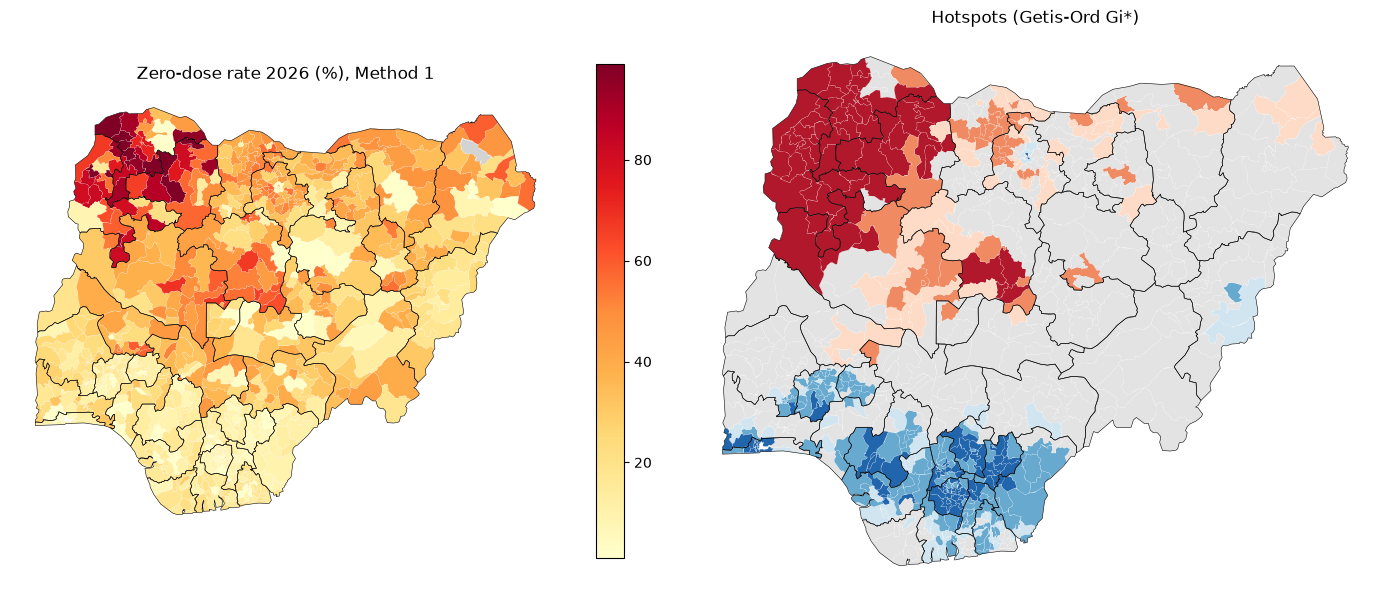

In [9]:
import geopandas as gpd, matplotlib.pyplot as plt
from esda.getisord import G_Local
from libpysal.weights import KNN, Queen
g = gpd.read_file(DATA_DIR / "nga_lgas.geojson"); gs = gpd.read_file(DATA_DIR / "nga_states.geojson")
keys = g.groupby("state_key")["lga_key"].apply(list).to_dict(); match = make_matcher(keys)
allk["state_key"] = allk.state.map(nstate)
allk["lga_key"] = [match(sk, l)[0] for sk, l in zip(allk.state_key, allk.lga_clean)]
assert allk.lga_key.notna().all(), "unmatched LGA names"
gm = g.merge(allk, on=["state_key", "lga_key"], how="left", suffixes=("_geo", "")).merge(L, on=["state", "lga_clean"], how="left")

def hot(z, p):
    for c in (0.01, 0.05, 0.10):
        if p <= c: return ("Hot" if z > 0 else "Cold") + f" Spot (p<{c:.2f})".replace("0.10", "0.10")
    return "Not Significant"
vals = gm.rate_2026.fillna(gm.rate_2026.median()).values
w = KNN.from_dataframe(gm, k=5); w.transform = "r"
gi = G_Local(vals, w, star=True, seed=42)
gm["hotspot"] = [hot(z, p) for z, p in zip(gi.Zs, gi.p_sim)]
print(gm.hotspot.value_counts().to_dict())
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
gm.plot(ax=ax[0], column="rate_2026", cmap="YlOrRd", legend=True, missing_kwds={"color": "lightgrey"}, linewidth=0.1, edgecolor="white")
gs.boundary.plot(ax=ax[0], color="black", linewidth=0.4); ax[0].set_title("Zero-dose rate 2026 (%), Method 1"); ax[0].axis("off")
pal = {"Hot Spot (p<0.01)": "#B2182B", "Hot Spot (p<0.05)": "#EF8A62", "Hot Spot (p<0.10)": "#FDDBC7", "Not Significant": "#E3E3E3",
       "Cold Spot (p<0.10)": "#D1E5F0", "Cold Spot (p<0.05)": "#67A9CF", "Cold Spot (p<0.01)": "#2166AC"}
gm.plot(ax=ax[1], color=gm.hotspot.map(pal), linewidth=0.1, edgecolor="white"); gs.boundary.plot(ax=ax[1], color="black", linewidth=0.4)
ax[1].set_title("Hotspots (Getis-Ord Gi*)"); ax[1].axis("off"); plt.tight_layout(); plt.show()

## 6. Agreement with independent data
* **NmDHS 2025-26** (Nigeria mini Demographic and Health Survey), released separately and not used to fit the model: compare state 2026 rates with 100 minus Penta1 coverage.
* **IHME Local Burden of Disease DTP1 (2018)**: an independent LGA map built by another team with different methods; eight years earlier, so it tests the geographic pattern, not 2026 levels. Spearman rank correlation with a bootstrap 95% confidence interval.

In [10]:
from scipy.stats import spearmanr
def spearman_ci(a, b, B=2000, seed=1):
    a, b = np.asarray(a, float), np.asarray(b, float); r = spearmanr(a, b); rg = np.random.default_rng(seed)
    bs = [spearmanr(a[i], b[i]).statistic for i in (rg.integers(0, len(a), len(a)) for _ in range(B))]
    return dict(rho=round(r.statistic, 3), p_value=float(r.pvalue), ci95=(round(np.percentile(bs, 2.5), 3), round(np.percentile(bs, 97.5), 3)), n=len(a))

nm = pd.read_csv(DATA_DIR / "nmdhs_2025_26_penta1_by_state_zone.csv")
v = state_res.merge(nm[nm.level == "state"].rename(columns={"area": "state"}), on="state")
print("NmDHS 2025-26 (37 states):", spearman_ci(v.rate_2026, v.zd_pct_100_minus_penta1),
      "| mean absolute error:", round((v.rate_2026 - v.zd_pct_100_minus_penta1).abs().mean(), 1), "percentage points")

ih = pd.read_csv(DATA_DIR / "ihme_dtp1_admin2_2018.csv")
ih["sk"] = ih.ADM1_NAME.map(nstate).replace({"nassarawa": "nasarawa", "abuja": "fct"}); ih["lk"] = ih.ADM2_NAME.map(nlga)
ik = ih.groupby("sk")["lk"].apply(list).to_dict()
look = {(s, l): v_ for s, l, v_ in zip(ih.sk, ih.lk, ih.dtp1_2018)}
def ihme_match(sk, lga):               # exact name, documented alias, then close match (cutoff 0.80)
    l = nlga(lga)
    if (sk, l) in look: return look[(sk, l)]
    a = ALIAS_POP.get((sk, l))
    if a and (sk, a) in look: return look[(sk, a)]
    c = difflib.get_close_matches(l, ik.get(sk, []), n=1, cutoff=0.80)
    return look[(sk, c[0])] if c else np.nan
L["ihme_zd_2018"] = 100 - np.array([ihme_match(nstate(s), l) for s, l in zip(L.state, L.lga_clean)], dtype=float)
d = L.dropna(subset=["ihme_zd_2018"]).copy()
d["ra"] = d.groupby("state").rate_2026.rank(pct=True); d["rb"] = d.groupby("state").ihme_zd_2018.rank(pct=True)
print("IHME 2018, national LGA ranking:", spearman_ci(d.rate_2026, d.ihme_zd_2018))
print("IHME 2018, ranking within states:", spearman_ci(d.ra, d.rb))

NmDHS 2025-26 (37 states): {'rho': np.float64(0.888), 'p_value': 2.1788798687470777e-13, 'ci95': (np.float64(0.722), np.float64(0.96)), 'n': 37} | mean absolute error: 6.3 percentage points


IHME 2018, national LGA ranking: {'rho': np.float64(0.65), 'p_value': 1.9159126773205649e-90, 'ci95': (np.float64(0.602), np.float64(0.695)), 'n': 743}


IHME 2018, ranking within states: {'rho': np.float64(0.078), 'p_value': 0.03448001658312847, 'ci95': (np.float64(0.002), np.float64(0.151)), 'n': 743}


## 7. Save outputs

In [11]:
cols = ["national_rank", "zone", "state", "lga_clean", "rate_2026", "rate_lo95", "rate_hi95", "children_2026", "children_lo95",
        "children_hi95", "p_top155", "rate_capped_99", "penta_1_count", "yr", "pop2022", "ihme_zd_2018"]
# posterior draws for uncertainty summaries (LGA order = rows of `best` before sorting; state draws for 2026)
order = L.set_index(["state", "lga_clean"])
np.savez_compressed(OUT_DIR / "method1_lga_draws_2026.npz", children=bd.astype("float32"), rate=rd.astype("float32"),
                    state=best.state.values, lga=best.lga_clean.values, state_rate=draws[2026][idx].astype("float32"),
                    states=np.array(states))
L[cols].rename(columns={"lga_clean": "lga", "penta_1_count": "penta1_doses_best_year", "yr": "penta1_best_year"}) \
      .to_csv(OUT_DIR / "method1_lga_estimates_2026.csv", index=False)
state_res.to_csv(OUT_DIR / "method1_state_forecasts_2026_2028.csv", index=False)
summ.to_csv(OUT_DIR / "method1_mcmc_diagnostics.csv")
json.dump(dict(national_children_2026=float(tot), lgas=int(len(L)), pareto=pareto, diagnostics=diag),
          open(OUT_DIR / "method1_summary.json", "w"), indent=2)
print("Saved:", sorted(p.name for p in OUT_DIR.glob("method1_*")))

Saved: ['method1_lga_draws_2026.npz', 'method1_lga_estimates_2026.csv', 'method1_mcmc_diagnostics.csv', 'method1_state_forecasts_2026_2028.csv', 'method1_summary.json']


## Notes and limitations
* Survey inputs are published NDHS state tables; survey design effects are not available, so the precision term uses the printed number of children.
* The LGA step distributes each state's modelled total using routine data patterns; it does not observe zero-dose prevalence at LGA level. LGA intervals reflect uncertainty in the state model only.
* Population denominators are projections from the 2006 census (2024 under-five projection; NPC 2022 LGA shares). Using the 2025 under-five file changes absolute numbers but not rates.
* Results can differ very slightly between computers (well under 1% for totals) because of Markov chain Monte Carlo sampling.